In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
tf = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

train_dl = DataLoader(
    datasets.ImageFolder("data/Training",tf),
    batch_size = 32,
    shuffle = True,
    num_workers = 4,
    pin_memory = True
)

test_dl = DataLoader(
    datasets.ImageFolder("data/Testing",tf),
    batch_size = 32,
    shuffle = False,
    num_workers = 4,
    pin_memory = True
)

In [5]:
class tumor_model(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Conv2d(in_channels = 3, out_channels = 32, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2),
            nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2),
            nn.Conv2d(in_channels = 64, out_channels = 128, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2),
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(in_features = 256, out_features = 4)
        ).to(device)
    def forward(self, x):
        return self.layer_stack(x)

In [6]:
model_1 = tumor_model()
optimizer = optim.Adam(params = model_1.parameters(), lr = 1e-4)
loss_fn = nn.CrossEntropyLoss()

In [7]:
model_1.train()

for epoch in range(25):
    running_loss = 0
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = loss_fn(model_1(x.to(device)), y.to(device))
        loss.backward()
        running_loss += loss
        optimizer.step()
    print(f"Epoch: {epoch} : Loss: {running_loss}")

KeyboardInterrupt: 

In [26]:
model_1.eval()
test_loss, correct = 0.0, 0

with torch.no_grad():
    for x, y in test_dl:
        x, y = x.to(device), y.to(device)
        logits = model_1(x)
        test_loss += loss_fn(logits, y).item() * y.size(0)
        preds = logits.argmax(dim = 1)
        correct += (preds == y).sum().item()
test_loss /= len(test_dl.dataset)
accuracy = 100.0 * correct/len(test_dl.dataset)

print(f"Test loss: {test_loss} | Test accuracy: {accuracy}")

Test loss: 0.14569327051982614 | Test accuracy: 97.02517162471396


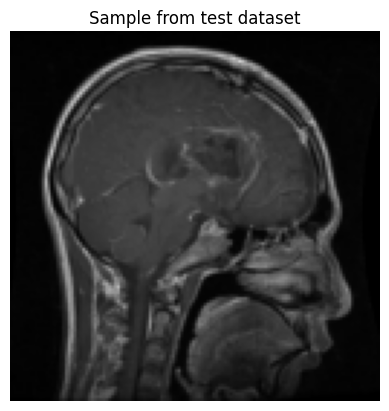

Predicted class : glioma
Ground Truth : glioma


In [34]:
import random
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image

model_1.eval()

idx = random.randrange(len(test_dl.dataset))
img, label = test_dl.dataset[idx]

unnormalize  = img * 0.5 + 0.5
plt.imshow(to_pil_image(unnormalize))
plt.axis("off")
plt.title("Sample from test dataset")
plt.show()

with torch.no_grad():
    logits = model_1(img.unsqueeze(0).to(device))
    pred = logits.argmax(dim = 1).item()
class_names = test_dl.dataset.classes
print(f"Predicted class : {class_names[pred]}")
print(f"Ground Truth : {class_names[label]}")

In [37]:
import os

os.makedirs("models", exist_ok = "True")
torch.save(model_1.state_dict(), "models/model_1.pth")

In [60]:
model_1 = tumor_model()
model_1.load_state_dict(torch.load("models/model_1.pth", map_location=device))

<All keys matched successfully>

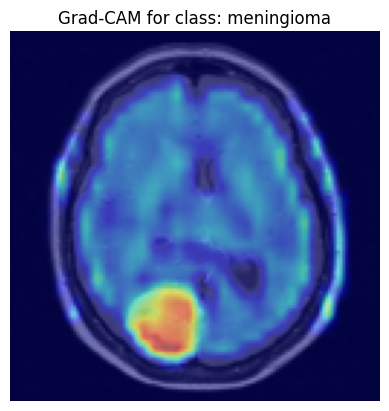

In [85]:
#Grad-CAM

import numpy as np
import random
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image

idx = random.randrange(len(test_dl.dataset))
idx = 310
img, label = test_dl.dataset[idx]
input_tensor = img.unsqueeze(0).to(device)

gradients = []
activations = []

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0].detach())

def forward_hook(module, input, output):
    activations.append(output.detach())

target_layer = model_1.layer_stack[4]
handle_fw = target_layer.register_forward_hook(forward_hook)
handle_bw = target_layer.register_full_backward_hook(backward_hook)

model_1.eval()
gradients.clear()
activations.clear()
output = model_1(input_tensor)
pred_class = output.argmax(dim = 1).item()

model_1.zero_grad()
score = output[0, pred_class]
score.backward()

grads = gradients[0]
acts = activations[0]

weights = grads.mean(dim = (2, 3), keepdim = True)
gradcam_map = (weights * acts).sum(dim = 1, keepdim = True)
gradcam_map = torch.relu(gradcam_map)
gradcam_map = torch.nn.functional.interpolate(gradcam_map, size = (128, 128), mode = "bilinear", align_corners = False )
gradcam_map = gradcam_map.squeeze().cpu().numpy()
gradcam_map = (gradcam_map - gradcam_map.min()) / (gradcam_map.max() - gradcam_map.min() + 1e-8)

plt.imshow(to_pil_image(img * 0.5 + 0.5))
plt.imshow(gradcam_map, cmap = "jet", alpha = 0.5)
plt.axis("off")
plt.title(f"Grad-CAM for class: {test_dl.dataset.classes[pred_class]}")
plt.show()

handle_fw.remove()
handle_bw.remove()

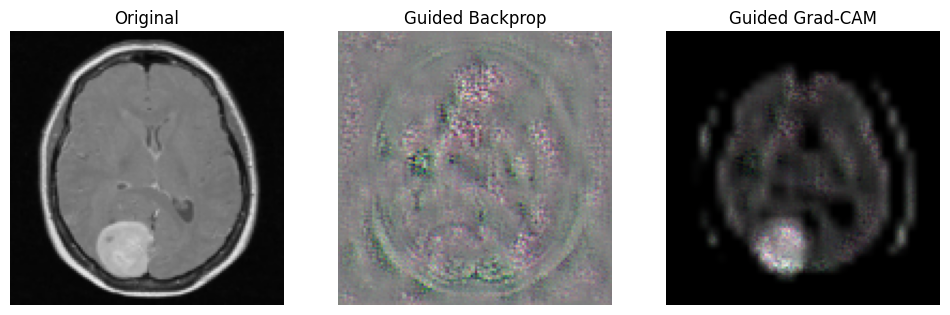

In [87]:
#Guided Grad-CAM
import torch
import torch.nn as nn

# Custom GuidedReLU
class GuidedReLU(nn.Module):
    def forward(self, input):
        positive_mask = (input > 0).type_as(input)
        output = torch.relu(input)
        self.save_for_backward = (input, positive_mask)
        return output

    def backward(self, grad_output):
        input, positive_mask = self.save_for_backward
        grad_input = grad_output.clone()
        grad_input[input <= 0] = 0
        grad_input[grad_output <= 0] = 0
        return grad_input

# Replace all ReLU with GuidedReLU
def replace_relu_with_guided(model):
    for name, module in model.named_children():
        if isinstance(module, nn.ReLU):
            setattr(model, name, GuidedReLU())
        else:
            replace_relu_with_guided(module)
replace_relu_with_guided(model_1)

# Guided Backpropagation
input_tensor.requires_grad = True
model_1.zero_grad()
output = model_1(input_tensor)
score = output[0, pred_class]
score.backward(retain_graph=True)
guided_grads = input_tensor.grad[0].cpu().numpy().transpose(1,2,0)
guided_grads = (guided_grads - guided_grads.min()) / (guided_grads.max() - guided_grads.min() + 1e-8)

# Guided Grad-CAM: element-wise multiply guided backprop and gradcam map
guided_gradcam = guided_grads * gradcam_map[..., None]
guided_gradcam = (guided_gradcam - guided_gradcam.min()) / (guided_gradcam.max() - guided_gradcam.min() + 1e-8)

# Visualize
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(to_pil_image(img * 0.5 + 0.5))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Guided Backprop")
plt.imshow(guided_grads)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Guided Grad-CAM")
plt.imshow(guided_gradcam)
plt.axis("off")

plt.show()